# Práctica 2 - Ejercicio 2

Asignatura: Programación para la Inteligencia Artificial

Alumno: Fernández Roldán, Daniel

Este es el segundo ejercicio de la Práctica 2 de Programación para la Inteligencia Artificial. Este ejercicio se debe entregar en un cuaderno de Jupyter separado del primero.

CIFAR100 es un conjunto de datos con dos niveles de etiquetado. Un etiquetado *fino* con 100 clases y un etiquetado *grueso* con 20 superclases. Se desea un sistema basado en neuronas lineales que tenga capacidad para realizar el etiquetado *fino*, pero se propone estudiar si la información que da el etiquetado *grueso* puede ayudar en la tarea aprovechando la probabilidad condicionada:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

Se espera una comparación entre la aproximación que usa solo un modelo neuronal para el etiquetado *fino* y la aproximación que incluye información del etiquetado *grueso*.

Información del conjunto de datos:

https://www.cs.toronto.edu/~kriz/cifar.html

Se espera el uso de las herramientas pertinentes tanto para completar el código como para realizar experimentos de los que se puedan extraer conclusiones sobre la capacidad del modelo entrenado. En el cuaderno se deben incluir los experimentos más relevantes.

Como conjunto de test se debe usar el conjunto de test íntegro que provee el conjunto de datos.

El cuaderno entregado debe llamarse ApellidosNombrePractica2Ejercicio2.ipynb

Consejos:
*  Cambiar el optimizador SGD por Adam. Lo veremos en clase próximamente :)
*  Normalizar los colores de las imágenes al rango [0,1].

In [21]:
# Import libraries.
import torch
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

import matplotlib.pyplot as plt

In [22]:
# Define the transformation to convert images to tensors.
transform = transforms.ToTensor()

# Load the training dataset with the specified transformation.
train_dataset = datasets.CIFAR100(
    root = './data', train = True, download = True, transform = transform
)

# Load the test dataset with the same transformation.
test_dataset = datasets.CIFAR100(
    root = './data', train = False, download = True, transform = transform
)

# Create data loaders for the training and test datasets with a batch size of 256.
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Get a batch of images and labels from the training data loader.
images, fine_labels = next(iter(train_loader))

# Define the mapping from fine labels to coarse labels.
coarse_mapping = torch.tensor([
    4, 1, 14, 8, 0, 6, 7, 7, 18, 3, 3, 14, 9, 18, 7, 11, 3, 9, 7, 11,
    6, 11, 5, 10, 7, 6, 13, 15, 3, 15, 0, 11, 1, 10, 12, 14, 16, 9, 11, 5,
    5, 19, 8, 8, 15, 13, 14, 17, 18, 10, 16, 4, 17, 4, 2, 0, 17, 4, 18, 17,
    10, 3, 2, 12, 12, 16, 12, 1, 9, 19, 2, 10, 0, 1, 16, 12, 9, 13, 15, 13,
    16, 19, 2, 4, 6, 19, 5, 5, 8, 19, 18, 1, 2, 15, 6, 0, 17, 8, 14, 13
])

# Map the fine labels to coarse labels using the defined mapping. (Translate fine labels to coarse labels.)
coarse_labels = coarse_mapping[fine_labels]

# Print the dimensions of the images and labels.
print("Dimension of the images:", images.shape)
print("Dimension of the fine labels:", fine_labels.shape)
print("Dimension of the coarse labels:", coarse_labels.shape)   

Dimension of the images: torch.Size([256, 3, 32, 32])
Dimension of the fine labels: torch.Size([256])
Dimension of the coarse labels: torch.Size([256])


In [23]:
# Define the CIFAR100 model architecture.
class CIFAR100_Model(nn.Module):
    def __init__(self):
        super(CIFAR100_Model, self).__init__()

        # Define the layers of the model.
        self.flatten = nn.Flatten()

        # Define the base layers of the model.
        self.base = nn.Sequential(
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        # Define the output layers for fine and coarse labels.
        self.fine_output = nn.Linear(256, 100)  # Output layer for fine labels (100 classes)

        # Define the output layer for coarse labels (20 classes).
        self.coarse_output = nn.Linear(256, 20)  # Output layer for coarse labels (20 classes)
    def forward(self, x):
        x = self.flatten(x)  # Flatten the input images.
        x= self.base(x)  # Pass through the base layers. In order to extract features from the images.

        coarse_prediction = self.coarse_output(x)  # Get coarse label predictions.
        fine_prediction = self.fine_output(x)  # Get fine label predictions.

        return coarse_prediction, fine_prediction  # Return both predictions.

In [24]:
model = CIFAR100_Model()  # Instantiate the model.

# Create a batch of random images with shape (4, 3, 32, 32). 
false_images = torch.randn(4, 3, 32, 32)  # (4 images, 3 color channels, 32x32 pixels)

coarse_pred, fine_pred = model(false_images)  # Get predictions for the random images.

print("Coarse predictions shape:", coarse_pred.shape)  # Print the shape of coarse predictions.
print("Fine predictions shape:", fine_pred.shape)  # Print the shape of fine predictions.

Coarse predictions shape: torch.Size([4, 20])
Fine predictions shape: torch.Size([4, 100])


In [25]:
loss_fn = nn.CrossEntropyLoss()  # Define the loss function for classification tasks.
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Define the optimizer (Adam) with a learning rate of 0.001.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Set the device to GPU if available, otherwise CPU.

# Define the training function for the base model.
def train_model_base(model, train_loader, loss_fn, optimizer, epochs=5, device=device):
    model.to(device)  # Move the model to the specified device (CPU or GPU).
    model.train()  # Set the model to training mode.
    historial_loss = []  # Initialize a list to store the loss for each epoch.
    historial_acc = []  # Initialize a list to store the accuracy for each epoch.

    for epoch in range(epochs):
        # Training loop for each epoch.
        loss_accumulated = 0.0  # Initialize the accumulated loss for the epoch.

        # Use tqdm to create a progress bar for the training loop.
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        # Iterate over batches of images and fine labels from the training data loader.
        for images, fine_labels in loop:
            images = images.to(device) # Move images to the specified device.
            fine_labels = fine_labels.to(device) # Move fine labels to the specified device.

            # 1. Forward pass: Get predictions from the model.
            coarse_pred, fine_pred = model(images)

            # 2. Clean gradients: Zero the gradients of the optimizer.
            optimizer.zero_grad()

            # 3. Calculate the loss using the fine label predictions and the true fine labels.
            loss = loss_fn(fine_pred, fine_labels)

            # 4. Backward pass: Compute gradients of the loss with respect to model parameters.
            loss.backward()

            # 5. Optimization step: Update model parameters based on computed gradients.
            optimizer.step()

            loss_accumulated += loss.item()  # Accumulate the loss for reporting.
            loop.set_postfix(loss=loss.item())  # Update the progress bar with the current loss.

        # After completing all batches in the epoch, calculate and store the mean loss for the epoch.
        historial_loss.append(loss_accumulated / len(train_loader))

        # Evaluation Phase
        model.eval()  # Set the model to evaluation mode for validation.
        good_predictions = 0  # Initialize a counter for correct predictions.
        total_predictions = 0  # Initialize a counter for total predictions.

        with torch.no_grad():
            for images, fine_labels in test_loader:
                images = images.to(device)  # Move images to the specified device.
                fine_labels = fine_labels.to(device)  # Move fine labels to the specified device.

                # Get predictions from the model.
                _, fine_pred = model(images)

                predicted_labels = torch.argmax(fine_pred, dim=1)  # Get the predicted labels by taking the argmax.

                good_predictions += (predicted_labels == fine_labels).sum().item()  # Count correct predictions.
                total_predictions += fine_labels.size(0)  # Count total predictions.

        accuracy = good_predictions / total_predictions  # Calculate accuracy for the epoch.
        historial_acc.append(accuracy)  # Store the accuracy for reporting.

        print(f"Mean loss for epoch {epoch+1}: {loss_accumulated / len(train_loader):.4f}, Accuracy: {accuracy:.4f}")  # Print the mean loss and accuracy for the epoch.

    return model, historial_loss, historial_acc  # Return the trained model after all epochs are completed.


In [26]:
coarse_mapping = coarse_mapping.to(device)  # Move the coarse mapping tensor to the specified device.

# Define the training function for the Bayesian model.
def train_model_bayes(model, train_loader, loss_fn, optimizer, epochs=5, device=device):
    model = model.to(device)  # Move the model to the specified device (CPU or GPU).
    # Training loop for each epoch.
    model.train()  # Set the model to training mode.
    historial_loss = []  # Initialize a list to store the loss for each epoch.
    historial_accuracy = []  # Initialize a list to store the accuracy for each epoch.

    for epoch in range(epochs):
        loss_accumulated = 0.0  # Initialize the accumulated loss for the epoch

        # Use tqdm to create a progress bar for the training loop.
        loop= tqdm(train_loader, desc=f"Training epoch {epoch+1}/{epochs}") 

        # Iterate over the training data.
        for images, fine_labels in loop:
            images = images.to(device)  # Move images to the specified device.
            fine_labels = fine_labels.to(device)  # Move fine labels to the specified device.

            coarse_labels = coarse_mapping[fine_labels]  # Map fine labels to coarse labels.

            # 1. Forward pass: Get predictions from the model.
            coarse_pred, fine_pred = model(images)  # Get predictions from the model.

            # 2. Clean gradients: Zero the gradients of the optimizer.
            optimizer.zero_grad()  # Zero the gradients of the optimizer.

            # 3. Calculate the loss using both coarse and fine label predictions.
            loss_coarse = loss_fn(coarse_pred, coarse_labels)  # Calculate loss for coarse predictions.
            loss_fine = loss_fn(fine_pred, fine_labels)  # Calculate loss for fine predictions.
            loss_total = loss_coarse + loss_fine  # Combine both losses.

            # 4. Backward pass: Compute gradients of the loss with respect to model parameters.
            loss_total.backward()  # Backpropagate the loss.

            # 5. Optimization step: Update model parameters based on computed gradients.
            optimizer.step()  # Update model parameters.

            loss_accumulated += loss_total.item()  # Accumulate the total loss for reporting.
            loop.set_postfix(loss=loss_total.item())  # Update the progress bar with the current total loss.

        # Validation step after each epoch.
        model.eval()  # Set the model to evaluation mode.
        good_predictions = 0  # Initialize the count of correct predictions.
        total_predictions = 0  # Initialize the total number of predictions.

        with torch.no_grad():  # Disable gradient calculation for validation.
            for images, fine_labels in test_loader:
                images = images.to(device)  # Move images to the specified device.
                fine_labels = fine_labels.to(device)  # Move fine labels to the specified device.

                coarse_pred, fine_pred = model(images)  # Get predictions from the model.

                coarse_prob = F.softmax(coarse_pred, dim=1)  # Convert coarse predictions to probabilities.
                fine_prob = F.softmax(fine_pred, dim=1)  # Convert fine predictions to probabilities.

                # Expand coarse probabilities to match the fine label dimensions using the coarse mapping.
                coarse_expanded_prob = coarse_prob[:, coarse_mapping]

                final_prob = fine_prob * coarse_expanded_prob  # Combine fine and coarse probabilities.

                # Get the predicted fine labels. Final class with mayor probability.
                predicted_labels = torch.argmax(final_prob, dim=1)

                good_predictions += (predicted_labels == fine_labels).sum().item()  # Count correct predictions.
                total_predictions += fine_labels.size(0)  # Update the total number of predictions.

        print(f"Mean loss for epoch {epoch+1}: {loss_accumulated / len(train_loader):.4f}, Accuracy: {good_predictions / total_predictions:.4f}")

        historial_loss.append(loss_accumulated / len(train_loader)) # Store the mean loss for the epoch.
        historial_accuracy.append(good_predictions / total_predictions) # Store the accuracy for the epoch.

    return model, historial_loss, historial_accuracy  # Return the trained model after all epochs are completed.

--- Training Base Model (Only Fine) ---


Epoch 1/5:   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 1/5: 100%|██████████| 196/196 [00:04<00:00, 46.24it/s, loss=4.03]


Mean loss for epoch 1: 4.1720, Accuracy: 0.1068


Epoch 2/5: 100%|██████████| 196/196 [00:04<00:00, 46.04it/s, loss=3.77]


...

Mean loss for epoch 3: 5.8647, Accuracy: 0.1662


Training epoch 4/5: 100%|██████████| 196/196 [00:04<00:00, 44.45it/s, loss=5.64]


Mean loss for epoch 4: 5.7002, Accuracy: 0.1680


Training epoch 5/5: 100%|██████████| 196/196 [00:04<00:00, 47.24it/s, loss=5.42]


Mean loss for epoch 5: 5.5649, Accuracy: 0.1853


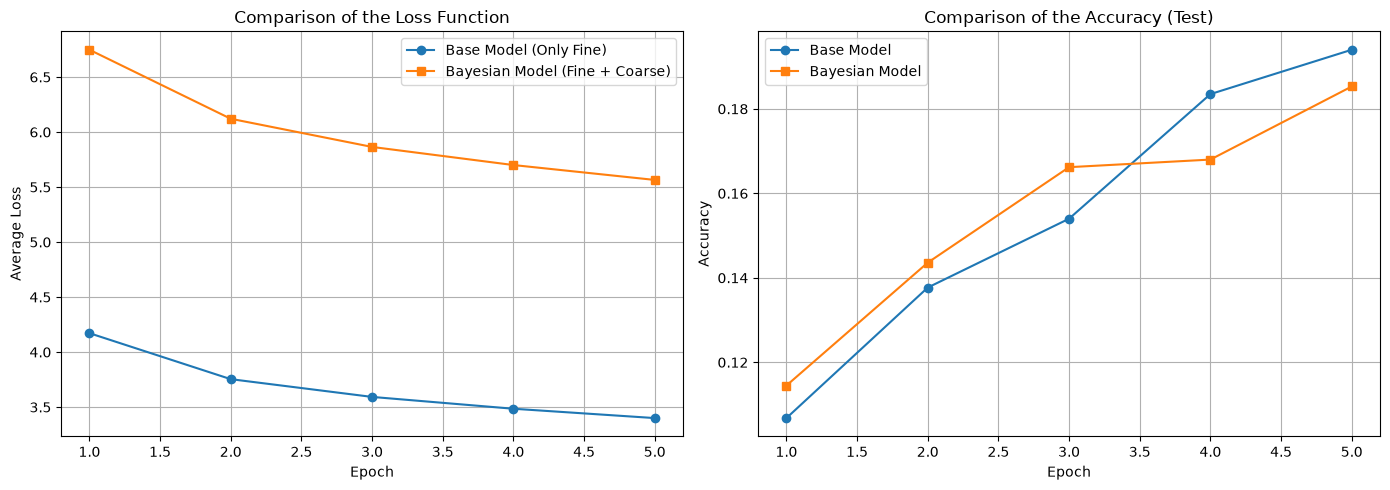

In [29]:
num_epochs = 5  # Define the number of epochs for training.

model_base = CIFAR100_Model()
optimizer_base = optim.Adam(model_base.parameters(), lr=0.001)

print("--- Training Base Model (Only Fine) ---")
_, base_loss, base_accuracy = train_model_base(
    model_base, 
    train_loader, 
    loss_fn, 
    optimizer_base, epochs=num_epochs, device=device)

model_bayes = CIFAR100_Model()
optimizer_bayes = optim.Adam(model_bayes.parameters(), lr=0.001)

print("\n--- Training Bayesian Model (Fine + Coarse) ---")
_, bayes_loss, bayes_accuracy = train_model_bayes(
    model_bayes,
    train_loader, 
    loss_fn, 
    optimizer_bayes, epochs=num_epochs, device=device)

# Adjusting automatically to the number of epochs used in training.
epochs_range = range(1, num_epochs + 1)  # Create a range of epochs for plotting. For the x-axis of the plots. 

plt.figure(figsize=(14, 5))  # Set the figure size for the plots.

# Loss Graph (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, base_loss, label='Base Model (Only Fine)', marker='o')
plt.plot(epochs_range, bayes_loss, label='Bayesian Model (Fine + Coarse)', marker='s')
plt.title('Comparison of the Loss Function')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.legend()
plt.grid(True)

# Accuracy Graph (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, base_accuracy, label='Base Model', marker='o')
plt.plot(epochs_range, bayes_accuracy, label='Bayesian Model', marker='s')
plt.title('Comparison of the Accuracy (Test)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:

# Asumimos que al entrenar guardaste los historiales en variables como estas:
# _, base_loss, base_acc = entrenar_modelo_base(...)
# _, bayes_loss, bayes_acc = entrenar_modelo_bayes(...)

epochs_range = range(1, 11) # Asumiendo 10 épocas

plt.figure(figsize=(14, 5))

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, base_loss, label='Modelo Base (Solo Fino)', marker='o')
plt.plot(epochs_range, bayes_loss, label='Modelo Bayes (Fino + Grueso)', marker='s')
plt.title('Comparación de la Función de Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida Media')
plt.legend()
plt.grid(True)

# Gráfica de Exactitud (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, base_acc, label='Modelo Base', marker='o')
plt.plot(epochs_range, bayes_acc, label='Modelo Bayes', marker='s')
plt.title('Comparación de la Exactitud (Accuracy) en Test')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()